In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [3]:
data = pd.read_csv("processed_label_data_uterus_transpose.csv")

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Class Distribution:")
print(y.value_counts())

Samples: 347
Features: 1881
Class Distribution:
Label
1    291
0     56
Name: count, dtype: int64


In [4]:
# 1. Remove low variance features
var_filter = VarianceThreshold(threshold=0.01)
X_var = var_filter.fit_transform(X)
selected_features = X.columns[var_filter.get_support()]
X = pd.DataFrame(X_var, columns=selected_features)

print("Features after variance filtering:", X.shape[1])

Features after variance filtering: 1247


In [5]:
#T-test on the features
significant_features = []

for col in X.columns:
    group0 = X[y == 0][col]
    group1 = X[y == 1][col]
    stat, p = ttest_ind(group0, group1, equal_var=False)
    if p < 0.05:
        significant_features.append(col)

X = X[significant_features]

print("Significant Features (p < 0.05):", X.shape[1])

Significant Features (p < 0.05): 932


In [6]:
# ANOVA
f_scores, p_vals = f_classif(X, y)
anova_rank = pd.Series(f_scores, index=X.columns).sort_values(ascending=False)

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_rank = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Top 10 ANOVA Features:")
display(anova_rank.head(10))

print("Top 10 MI Features:")
display(mi_rank.head(10))

Top 10 ANOVA Features:


hsa-mir-99a       310.255188
hsa-mir-145       262.348245
hsa-mir-29a       222.260485
hsa-mir-548aw     187.933198
hsa-mir-100       187.621419
hsa-mir-139       172.294049
hsa-mir-4536-1    161.806658
hsa-mir-1-2       158.951743
hsa-mir-1-1       156.168230
hsa-mir-4536-2    155.003238
dtype: float64

Top 10 MI Features:


hsa-mir-93      0.304260
hsa-mir-7-2     0.266307
hsa-mir-1307    0.261467
hsa-mir-7-3     0.261256
hsa-mir-130b    0.254832
hsa-mir-1301    0.248407
hsa-mir-143     0.243938
hsa-mir-200a    0.243158
hsa-mir-200c    0.240711
hsa-mir-191     0.236519
dtype: float64

In [16]:
#Novel Method: CSSS=∣μ1−μ0|/(σ1+σ0)
def compute_csss(X, y, cv):
    csss_scores = pd.Series(0.0, index=X.columns)
    for train_idx, _ in cv.split(X, y):
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        X0 = X_train[y_train == 0]
        X1 = X_train[y_train == 1]

        mu_diff = abs(X1.mean() - X0.mean())
        std_sum = X1.std() + X0.std()

        fold_score = (mu_diff / std_sum).replace([np.inf, -np.inf], 0).fillna(0)
        csss_scores += fold_score

    return (csss_scores / cv.get_n_splits()).sort_values(ascending=False)


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
csss_rank = compute_csss(X, y, cv)

print("Top 10 CSSS Features:")
display(csss_rank.head(10))

Top 10 CSSS Features:


hsa-mir-29a      1.087211
hsa-mir-145      0.997134
hsa-mir-99a      0.973299
hsa-mir-100      0.942183
hsa-mir-200c     0.940950
hsa-mir-425      0.939983
hsa-mir-200b     0.924385
hsa-mir-21       0.903189
hsa-mir-200a     0.842214
hsa-mir-548aw    0.822834
dtype: float64

In [8]:
#K-fold Cross validation
top_k = min(100, X.shape[1])
selected = anova_rank.index[:top_k]
X_model = X[selected]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Linear SVM": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1)
}

results = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_scaled,
        y,
        cv=cv,
        scoring=['accuracy','precision','recall','f1'],
        n_jobs=-1
    )
    
    results[name] = {
        metric: np.mean(scores[f'test_{metric}'])
        for metric in ['accuracy','precision','recall','f1']
    }

pd.DataFrame(results).T

,accuracy,precision,recall,f1
Logistic Regression,0.968403,0.982963,0.979425,0.980930
Linear SVM,0.942521,0.966291,0.965632,0.965496
Random Forest,0.982857,0.986659,0.993103,0.989768


In [17]:
#GridsearchCv for Hyperparameter tuning
best_model_name = max(results, key=lambda k: results[k]['f1'])
print("Best Baseline Model:", best_model_name)

if best_model_name == "Random Forest":
    param_grid = {
        "n_estimators": [200, 300],
        "max_depth": [None, 10, 20]
    }
    base_model = RandomForestClassifier(n_jobs=-1)

elif best_model_name == "Linear SVM":
    param_grid = {"C": [0.01, 0.1, 1, 10]}
    base_model = SVC(kernel='linear')

else:
    param_grid = {"C": [0.01, 0.1, 1, 10]}
    base_model = LogisticRegression(max_iter=5000)

grid = GridSearchCV(base_model, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_scaled, y)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", grid.best_score_)

Best Baseline Model: Random Forest
Best Parameters: {'max_depth': 10, 'n_estimators': 300}
Best F1 Score: 0.9914630786564864


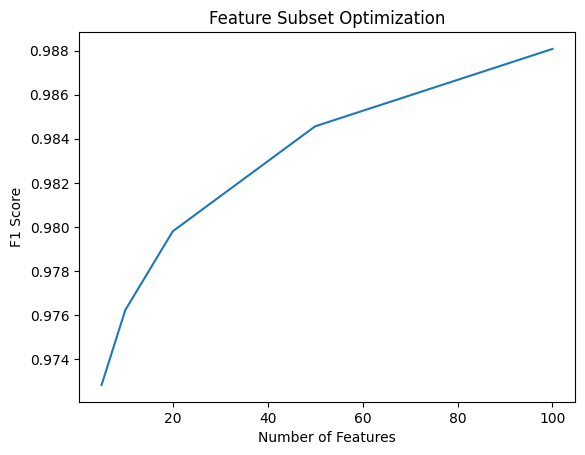

,Features,F1 Score
0,5,0.972838
1,10,0.976233
2,20,0.979805
3,50,0.984564
4,100,0.988073


In [15]:
#Optimal feature subset Search 
subset_sizes = [5, 10, 20, 50, 100]
subset_sizes = [k for k in subset_sizes if k <= X.shape[1]]

f1_scores = []

for k in subset_sizes:
    selected = anova_rank.index[:k]
    X_sub = StandardScaler().fit_transform(X[selected])

    scores = cross_validate(
        grid.best_estimator_,
        X_sub,
        y,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )
    f1_scores.append(np.mean(scores['test_score']))

plt.figure()
plt.plot(subset_sizes, f1_scores)
plt.xlabel("Number of Features")
plt.ylabel("F1 Score")
plt.title("Feature Subset Optimization")
plt.savefig("img.png")
plt.show()
pd.DataFrame({"Features": subset_sizes, "F1 Score": f1_scores})